# Drift Benchmark — Series de Tiempo con Etiquetas (Seasonal, Golden, Decay)


Este notebook genera **tres datasets sintéticos etiquetados** para evaluar tus **tres estrategias** (`decay`, `golden`, `seasonal`) con `drift_funcs.py`.

Métricas: **Accuracy, Precision, Recall, F1**, y **Detection Delay** por estrategia y dataset.


In [12]:

from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import importlib.util, sys

# Cargar drift_funcs.py
drift_path = Path('drift_funcs.py')
spec = importlib.util.spec_from_file_location('drift_funcs', drift_path)
drift_funcs = importlib.util.module_from_spec(spec)
sys.modules['drift_funcs'] = drift_funcs
spec.loader.exec_module(drift_funcs)

OUT = Path('/mnt/data/benchmark_outputs')
OUT.mkdir(parents=True, exist_ok=True)

print('✓ drift_funcs.py cargado desde:', drift_path)
print('✓ Carpeta de salida:', OUT)

✓ drift_funcs.py cargado desde: drift_funcs.py
✓ Carpeta de salida: \mnt\data\benchmark_outputs


In [13]:
import pandas as pd, numpy as np

def make_seasonal(
    n_days=180, freq='H',
    weekly_amp=5.0, seasonal_shift=6.0,
    shift_starts=('2024-03-01','2024-05-15')
):
    # cantidad de pasos
    steps = int(pd.Timedelta(days=n_days) / pd.Timedelta("1"+freq))
    t = pd.date_range('2024-01-01', periods=steps, freq=freq)

    # patrón semanal en Series (mutable)
    phase = (t.dayofweek*24 + t.hour) / (24*7)
    base = 10 + weekly_amp * np.sin(2*np.pi * phase)
    x = pd.Series(base.astype(float), index=t)

    # etiquetas (0/1) y shifts estacionales
    labels = pd.Series(0, index=t, dtype=int)
    for s in shift_starts:
        s = pd.Timestamp(s)
        labels.loc[labels.index >= s] = 1
        x.loc[x.index >= s] = x.loc[x.index >= s] + seasonal_shift

    df = pd.DataFrame({'date_time': t, 'sensor_A': x.values})
    return df, labels


def make_golden(
    n_days=200, freq='H',
    batch_len_days=20, level_jump=4.0, noise=0.3
):
    steps = int(pd.Timedelta(days=n_days) / pd.Timedelta("1"+freq))
    t = pd.date_range('2024-01-01', periods=steps, freq=freq)

    batch_len = int(pd.Timedelta(days=batch_len_days) / pd.Timedelta("1"+freq))
    levels = []
    level = 10.0
    labels = pd.Series(0, index=t, dtype=int)

    for i in range(steps):
        if i % batch_len == 0 and i > 0:
            level += level_jump
            labels.iloc[i:] = 1
        levels.append(level + np.random.normal(0, noise))

    x = pd.Series(levels, index=t)
    df = pd.DataFrame({'date_time': t, 'sensor_B': x.values})
    return df, labels


def make_decay(
    n_days=120, freq='H',
    change_start='2024-03-10', total_shift=5.0
):
    steps = int(pd.Timedelta(days=n_days) / pd.Timedelta("1"+freq))
    t = pd.date_range('2024-01-01', periods=steps, freq=freq)

    x = pd.Series(10 + np.random.normal(0, 0.5, steps), index=t)

    change_start = pd.Timestamp(change_start)
    mask = x.index >= change_start
    ramp = np.linspace(0, total_shift, mask.sum()) if mask.any() else np.array([])
    if mask.any():
        x.loc[mask] = x.loc[mask].values + ramp

    labels = pd.Series(0, index=t, dtype=int)
    labels.loc[mask] = 1

    df = pd.DataFrame({'date_time': t, 'sensor_C': x.values})
    return df, labels


In [14]:
# === Crear datasets etiquetados ===
df_seasonal, y_seasonal = make_seasonal(
    n_days=180, freq='H',
    weekly_amp=5.0, seasonal_shift=6.0,
    shift_starts=('2024-03-01','2024-05-15')
)

df_golden, y_golden = make_golden(
    n_days=200, freq='H',
    batch_len_days=20, level_jump=4.0, noise=0.3
)

df_decay, y_decay = make_decay(
    n_days=120, freq='H',
    change_start='2024-03-10', total_shift=5.0
)

# Guardar por trazabilidad (opcional)
df_seasonal.to_csv(OUT/'seasonal.csv', index=False)
df_golden.to_csv(OUT/'golden.csv', index=False)
df_decay.to_csv(OUT/'decay.csv', index=False)

print('✓ Datasets listos:', len(df_seasonal), len(df_golden), len(df_decay))


✓ Datasets listos: 4320 4800 2880


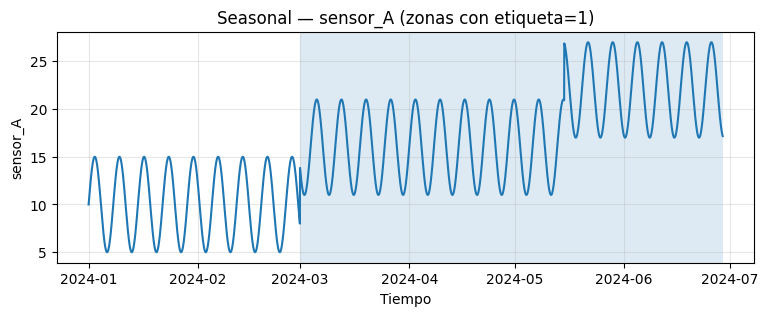

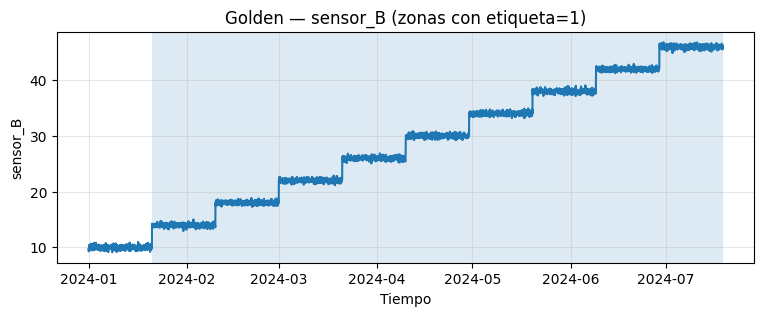

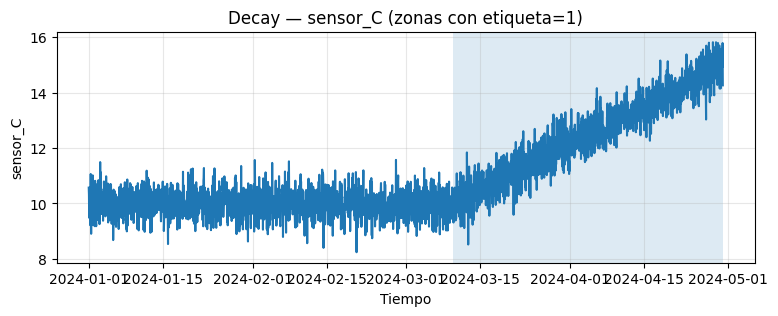

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_with_labels(df, col, labels, title):
    t = pd.to_datetime(df['date_time'])
    y = df[col].values

    plt.figure(figsize=(9,3))
    plt.plot(t, y)
    plt.title(title); plt.xlabel('Tiempo'); plt.ylabel(col)
    plt.grid(True, alpha=0.3)

    # sombrear zonas con label==1 (drift activo)
    mask = labels.astype(bool)
    if mask.any():
        # encontrar intervalos [start, end] de label==1
        starts = (mask & ~mask.shift(1, fill_value=False))
        ends   = (mask & ~mask.shift(-1, fill_value=False))
        start_times = t[starts.values]
        end_times   = t[ends.values] if ends.any() else [t.iloc[-1]]
        # si el drift se mantiene hasta el final y no hay 'ends', ciérralo en el último punto
        if len(end_times) < len(start_times):
            end_times = list(end_times) + [t.iloc[-1]]
        for s, e in zip(start_times, end_times):
            plt.axvspan(s, e, alpha=0.15)

# Dibujar
plot_with_labels(df_seasonal, 'sensor_A', y_seasonal, 'Seasonal — sensor_A (zonas con etiqueta=1)')
plot_with_labels(df_golden,   'sensor_B', y_golden,   'Golden — sensor_B (zonas con etiqueta=1)')
plot_with_labels(df_decay,    'sensor_C', y_decay,    'Decay — sensor_C (zonas con etiqueta=1)')
plt.show()


In [16]:

from typing import List, Dict
def evaluate_over_time(
    df: pd.DataFrame,
    label_series: pd.Series,
    strategies: List[str],
    CURRENT_WINDOW: str = '7D',
    RESAMPLE: str | None = None,
    RESAMPLE_AGG: str = 'median',
    EXCLUDE_COLUMNS: List[str] = None,
    step_hours: int = 24,
    eval_horizon_days: int = 60,
    extra_kwargs: Dict = None
) -> pd.DataFrame:
    if EXCLUDE_COLUMNS is None: EXCLUDE_COLUMNS = []
    if extra_kwargs is None: extra_kwargs = {}
    dt = 'date_time'
    df = df.copy()
    df[dt] = pd.to_datetime(df[dt])
    df = df.sort_values(dt)
    t_min, t_max = df[dt].min(), df[dt].max()
    t_start_eval = t_min + pd.Timedelta(eval_horizon_days, unit='D')
    results = []
    for t_end in pd.date_range(t_start_eval, t_max, freq=f'{step_hours}H'):
        df_cut = df[df[dt] <= t_end].copy()
        if df_cut.empty:
            continue
        for strat in strategies:
            out_dir = OUT / 'tmp_eval'
            out_dir.mkdir(parents=True, exist_ok=True)
            try:
                drift_funcs.make_report_for_plant(
                    df=df_cut,
                    output_dir=out_dir,
                    strategy=strat,
                    CURRENT_WINDOW=CURRENT_WINDOW,
                    RESAMPLE=RESAMPLE,
                    RESAMPLE_AGG=RESAMPLE_AGG,
                    EXCLUDE_COLUMNS=EXCLUDE_COLUMNS,
                    NUM_METHOD='auto',
                    NUM_THRESHOLD=None,
                    plant_name='eval',
                    flag_csv=None,
                    SAVE_HTML=False,
                    **extra_kwargs
                )
                metrics_path = out_dir / f"eval_{strat}_metrics.csv"
                det = 0
                if metrics_path.exists():
                    m = pd.read_csv(metrics_path)
                    det = int(bool(m['drift_detected'].fillna(False).any()))
            except Exception:
                det = 0
            # etiqueta temporal
            y_true = int(label_series.loc[label_series.index<=t_end].tail(1).values[0])
            results.append({'t_end': t_end, 'strategy': strat, 'detected': det, 'y_true': y_true})
    return pd.DataFrame(results)

In [18]:

strategies = ['decay','golden','seasonal']
ev_seasonal = evaluate_over_time(df_seasonal, y_seasonal, strategies, CURRENT_WINDOW='7D', step_hours=12, eval_horizon_days=14)
ev_golden   = evaluate_over_time(df_golden,   y_golden,   strategies, CURRENT_WINDOW='5D', step_hours=12, eval_horizon_days=14)
ev_decay    = evaluate_over_time(df_decay,    y_decay,    strategies, CURRENT_WINDOW='5D', step_hours=12, eval_horizon_days=14)

for name, ev in [('seasonal', ev_seasonal), ('golden', ev_golden), ('decay', ev_decay)]:
    ev.to_csv(OUT / f'eval_{name}.csv', index=False)
    print(f'✓ eval_{name}.csv guardado ({len(ev)} filas)')

✓ eval_seasonal.csv guardado (996 filas)
✓ eval_golden.csv guardado (1116 filas)
✓ eval_decay.csv guardado (636 filas)


In [19]:
def summarize_scores(ev_df: pd.DataFrame) -> pd.DataFrame:
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    rows = []
    for strat, g in ev_df.groupby('strategy'):
        y_true = g['y_true'].values
        y_pred = g['detected'].values
        if y_true.sum() == 0:
            prec = rec = f1 = np.nan
        else:
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec  = recall_score(y_true, y_pred, zero_division=0)
            f1   = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        rows.append({'strategy': strat, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    return pd.DataFrame(rows).sort_values('f1', ascending=False)

def detection_delay(ev_df: pd.DataFrame, label_series: pd.Series) -> pd.DataFrame:
    label_series = label_series.sort_index()
    changes = label_series[(label_series.shift(fill_value=0)==0) & (label_series==1)].index
    rows = []
    for strat, g in ev_df.groupby('strategy'):
        g = g.sort_values('t_end')
        delays = []
        for ch in changes:
            future = g[g['t_end'] >= ch]
            first_det = future[future['detected']==1]['t_end'].head(1)
            if len(first_det):
                delay_h = (pd.Timestamp(first_det.iloc[0]) - pd.Timestamp(ch)).total_seconds()/3600.0
                if delay_h >= 0:
                    delays.append(delay_h)
        rows.append({'strategy': strat, 'mean_delay_hours': np.mean(delays) if delays else np.nan, 'n_changes': len(changes), 'n_detected': len(delays)})
    return pd.DataFrame(rows).sort_values('mean_delay_hours')

# construir un tablero único
dash = []

for dataset_name, ev, labels in [
    ('seasonal', ev_seasonal, y_seasonal),
    ('golden',   ev_golden,   y_golden),
    ('decay',    ev_decay,    y_decay),
]:
    sc = summarize_scores(ev).rename(columns=lambda c: f'{dataset_name}_{c}' if c!='strategy' else c)
    dl = detection_delay(ev, labels).rename(columns=lambda c: f'{dataset_name}_{c}' if c!='strategy' else c)
    merged = sc.merge(dl, on='strategy', how='left')
    dash.append(merged)

dashboard = dash[0].merge(dash[1], on='strategy', how='outer').merge(dash[2], on='strategy', how='outer')
dashboard.to_csv(OUT/'dashboard_comparativo.csv', index=False)
dashboard


,strategy,seasonal_accuracy,seasonal_precision,seasonal_recall,seasonal_f1,seasonal_mean_delay_hours,seasonal_n_changes,seasonal_n_detected,golden_accuracy,golden_precision,...,golden_mean_delay_hours,golden_n_changes,golden_n_detected,decay_accuracy,decay_precision,decay_recall,decay_f1,decay_mean_delay_hours,decay_n_changes,decay_n_detected
0,decay,0.638554,1.0,0.5000,0.666667,36.0,1,1,0.983871,0.991667,...,0.0,1,1,0.933962,0.940000,0.921569,0.930693,96.0,1,1
1,golden,0.990964,1.0,0.9875,0.993711,36.0,1,1,0.991935,0.991736,...,0.0,1,1,0.938679,0.958763,0.911765,0.934673,108.0,1,1
2,seasonal,0.340361,1.0,0.0875,0.160920,336.0,1,1,0.919355,1.000000,...,360.0,1,1,0.674528,0.597633,0.990196,0.745387,0.0,1,1


In [20]:

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np, pandas as pd

def summarize_scores(ev_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for strat, g in ev_df.groupby('strategy'):
        y_true = g['y_true'].values
        y_pred = g['detected'].values
        if y_true.sum() == 0:
            prec = rec = f1 = np.nan
        else:
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec  = recall_score(y_true, y_pred, zero_division=0)
            f1   = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        rows.append({'strategy': strat, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    return pd.DataFrame(rows).sort_values('f1', ascending=False)

def detection_delay(ev_df: pd.DataFrame, label_series: pd.Series) -> pd.DataFrame:
    label_series = label_series.sort_index()
    changes = label_series[(label_series.shift(fill_value=0)==0) & (label_series==1)].index
    rows = []
    for strat, g in ev_df.groupby('strategy'):
        g = g.sort_values('t_end')
        delays = []
        for ch in changes:
            future = g[g['t_end'] >= ch]
            first_det = future[future['detected']==1]['t_end'].head(1)
            if len(first_det):
                delay_h = (pd.Timestamp(first_det.iloc[0]) - pd.Timestamp(ch)).total_seconds()/3600.0
                if delay_h >= 0:
                    delays.append(delay_h)
        rows.append({'strategy': strat, 'mean_delay_hours': np.mean(delays) if delays else np.nan, 'n_changes': len(changes), 'n_detected': len(delays)})
    return pd.DataFrame(rows).sort_values('mean_delay_hours')

scores_seasonal = summarize_scores(ev_seasonal); delay_seasonal = detection_delay(ev_seasonal, y_seasonal)
scores_golden   = summarize_scores(ev_golden);   delay_golden   = detection_delay(ev_golden,   y_golden)
scores_decay    = summarize_scores(ev_decay);    delay_decay    = detection_delay(ev_decay,    y_decay)

scores_seasonal.to_csv(OUT/'scores_seasonal.csv', index=False)
scores_golden.to_csv(OUT/'scores_golden.csv', index=False)
scores_decay.to_csv(OUT/'scores_decay.csv', index=False)
delay_seasonal.to_csv(OUT/'delay_seasonal.csv', index=False)
delay_golden.to_csv(OUT/'delay_golden.csv', index=False)
delay_decay.to_csv(OUT/'delay_decay.csv', index=False)

scores_seasonal, delay_seasonal

(   strategy  accuracy  precision  recall        f1
 1    golden  0.990964        1.0  0.9875  0.993711
 0     decay  0.638554        1.0  0.5000  0.666667
 2  seasonal  0.340361        1.0  0.0875  0.160920,
    strategy  mean_delay_hours  n_changes  n_detected
 0     decay              36.0          1           1
 1    golden              36.0          1           1
 2  seasonal             336.0          1           1)

In [ ]:

def barplot_scores(df: pd.DataFrame, title: str):
    plt.figure()
    x = np.arange(len(df)); vals = df['f1'].fillna(0).values
    plt.bar(x, vals); plt.xticks(x, df['strategy']); plt.title(title)
    for i,v in enumerate(vals): plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

def barplot_delay(df: pd.DataFrame, title: str):
    plt.figure()
    x = np.arange(len(df)); vals = df['mean_delay_hours'].fillna(0).values
    plt.bar(x, vals); plt.xticks(x, df['strategy']); plt.title(title)
    for i,v in enumerate(vals): plt.text(i, v, f"{v:.1f}h", ha='center', va='bottom')

barplot_scores(scores_seasonal, 'F1 — seasonal'); barplot_delay(delay_seasonal, 'Delay — seasonal')
barplot_scores(scores_golden,   'F1 — golden');   barplot_delay(delay_golden,   'Delay — golden')
barplot_scores(scores_decay,    'F1 — decay');    barplot_delay(delay_decay,    'Delay — decay')